## 画各类酶的预测分布

In [ ]:
import os
import torch
Type = "kkm"
# 加载测试集信息
testPairInfo = torch.load(f"../Data/{Type.upper()}TestPairInfo")
# 加载训练集信息
# trainPairInfo = torch.load("../Data/KMTestPairInfo")
# 加载序列和分子索引
indexSeq = torch.load(f"../../{Type.upper()}/Data/NewestFeature/index_seq")
indexSmiles = torch.load(f"../../{Type.upper()}/Data/NewestFeature/index_smiles")
# 加载全数据集索引
dataInfo = torch.load("../../KCAT/Data/all_kinetics_data.pt")

# mapping
from collections import defaultdict
Ecs = defaultdict(list)
for item in testPairInfo:
#     rawDataInfo.append(dataInfo['kinetics_data']['kcat'][item[3][0]])
    if len(item[3]) < 2: 
        key = dataInfo['kinetics_data'][Type][item[3][0]]['ec'][0]
        Ecs[key].append(item)

Ecs = dict(Ecs)
import sys
sys.path.append("../")
from tools import getPairInfo, metric
from predictor_base import predict
ECsPerf = {}
modelPath = {
    'kcat':"../../IterTransferLearning/KCATModel/confirm-MACCS#openKKmInfer#openLog10-KCAT-train-1/model/pre-train-trainR2:0.9161-devR2=0.6674-RMSE=0.8867-MAE=0.5639-epoch=100",
    'km':"../../IterTransferLearning/KMModel/confirm-MACCS#openKKmInfer#openLog10-KM-train-1/model/pre-train-trainR2:0.8980-devR2=0.6307-RMSE=0.7941-MAE=0.5537-epoch=100",
    'kkm':"../../KKM/TrainInfo/models/initialTrain-MACCSKeys/ECFPKKmPredictor-trainR2:0.8893-devR2=0.6136-RMSE=1.1116-MAE=0.7944-epoch=100"
}
for k, v in Ecs.items():
    real, pre = predict(
                    Type.upper(),
                    modelPath[Type],
                    v,
                    f"../../{Type.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                    f"../../{Type.upper()}/Data/NewestFeature/index_smiles",
                    False if Type == 'kkm' else True,
                    torch.device("cuda:0"),
                    "MACCSKeys"
                   )
    ECsPerf[k] = metric(pre, real, True)
    ECsPerf[k]['MeanReal'] = sum(real) / len(real)
    ECsPerf[k]['MeanPre'] = sum(pre) / len(pre)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
import math

plt.figure(figsize=(4,4))
rc('font',**{'family':'Times New Roman',})
plt.rcParams['pdf.fonttype'] = 42
# plt.axes([0.12,0.12,0.83,0.83])
plt.tick_params(direction='in')
plt.tick_params(which='major',length=2)
plt.tick_params(which='major',width=1)

labels = ["Oxidoreductases", "Transferases", "Hydrolases", "Lyases", "Isomerases", "Ligases"]

if Type == 'kcat':
    x = np.linspace(0, 1.2, 1000)
elif Type == 'km':
    x = np.linspace(-1.0, 0.5, 1000)
else:
    x = np.linspace(0, 5, 1000)
plt.plot(x, x, linestyle='--', alpha=0.5)
for k, v in ECsPerf.items():
    if k != '7':
        if Type == 'kcat':
            plt.scatter(v['MeanReal'], v['MeanPre'], s=2.5**(v['MAE']*10), label=labels[int(k)-1], alpha=0.5)
        elif Type == 'km':
            plt.scatter(v['MeanReal'], v['MeanPre'], s=2.8**(v['MAE']*10), label=labels[int(k)-1], alpha=0.5)
        else:
            plt.scatter(v['MeanReal'], v['MeanPre'], s=1.24**(v['MAE']*10), label=labels[int(k)-1], alpha=0.5)
        print(k,':',v)
if Type != 'kkm': 
    plt.ylabel("Mean Predictive $K_{%s}$ Log10-scaled Value"%Type[1:],fontdict={'weight': 'normal', 'fontname': 'Times New Roman', 'size': 12},)
    plt.xlabel("Mean Experimental $K_{%s}$ Log10-scaled Value"%Type[1:],fontdict={'weight': 'normal', 'fontname': 'Times New Roman', 'size': 12},)
else:
    plt.ylabel("Mean Predictive $KK_{%s}$ Log10-scaled Value"%Type[2:],fontdict={'weight': 'normal', 'fontname': 'Times New Roman', 'size': 12},)
    plt.xlabel("Mean Experimental $KK_{%s}$ Log10-scaled Value"%Type[2:],fontdict={'weight': 'normal', 'fontname': 'Times New Roman', 'size': 12},)
plt.legend(markerscale = 0.7)

plt.savefig(f"../Fig/Fig2-MACCSKeys-{Type}-TestDataset.png", dpi=600, bbox_inches='tight')
plt.show()

# iter 8

In [32]:
import os
import torch
Type = "kkm"
# 加载测试集信息
testPairInfo = torch.load(f"../Data/{Type.upper()}TestPairInfo")
# 加载训练集信息
# trainPairInfo = torch.load("../Data/KMTestPairInfo")
# 加载序列和分子索引
indexSeq = torch.load(f"../../{Type.upper()}/Data/NewestFeature/index_seq")
indexSmiles = torch.load(f"../../{Type.upper()}/Data/NewestFeature/index_smiles")
# 加载全数据集索引
dataInfo = torch.load("../../KCAT/Data/all_kinetics_data.pt")

# mapping
from collections import defaultdict
Ecs = defaultdict(list)
for item in testPairInfo:
#     rawDataInfo.append(dataInfo['kinetics_data']['kcat'][item[3][0]])
    if len(item[3]) < 2: 
        key = dataInfo['kinetics_data'][Type][item[3][0]]['ec'][0]
        Ecs[key].append(item)

Ecs = dict(Ecs)
import sys
sys.path.append("../")
from tools import getPairInfo, metric
from predictor_iter import predict
ECsPerf = {}
# ae = {}
modelPath = {
    'kcat':"../../IterTransferLearning/KCATModel/confirm-MACCS#openKKmInfer#openLog10-KCAT-train-8/model/pre-train-trainR2:0.9408-devR2=0.7459-RMSE=0.7751-MAE=0.4787-epoch=3",
    'km':"../../IterTransferLearning/KMModel/confirm-MACCS#openKKmInfer#openLog10-KM-train-8/model/pre-train-trainR2:0.9303-devR2=0.7163-RMSE=0.6960-MAE=0.4802-epoch=3",
    'kkm':"../../IterTransferLearning/KKMModel/confirm-MACCS#openKKmInfer#openLog10-KKM-train-8/model/pre-train-trainR2:0.9188-devR2=0.8245-RMSE=0.7592-MAE=0.5030-epoch=4"
}
for k, v in Ecs.items():
    real, pre = predict(
                    Type.upper(),
                    modelPath[Type],
                    v,
                    f"../../{Type.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                    f"../../{Type.upper()}/Data/NewestFeature/index_smiles",
                    True,
                    torch.device("cuda:0"),
                    "MACCSKeys"
                   )
    ECsPerf[k] = metric(pre, real, True)
    real = np.array(real)
    pre = np.array(pre)
    ECsPerf[k]['meanReal'] = np.mean(real)
    ECsPerf[k]['MeanPre'] = np.mean(pre)
#     ECsPerf[k]['MeanReal'] = sum(real) / len(real)
#     ECsPerf[k]['MeanPre'] = sum(pre) / len(pre)
#     ae[k] = np.abs(np.array(pre) - np.array(real))

log10:True molType:MACCSKeys
complex
complex


100%|███████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.16it/s]


log10:True molType:MACCSKeys
complex
complex


100%|███████████████████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.10it/s]


log10:True molType:MACCSKeys
complex
complex


...

100%|███████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.59s/it]


log10:True molType:MACCSKeys
complex
complex


100%|███████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.87s/it]


log10:True molType:MACCSKeys
complex
complex


100%|███████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.95s/it]


1 : {'MAE': 0.48946895432704485, 'rmse': 0.7890047361509958, 'r2': 0.7072161206159895, 'r': 0.8421148257142842, 'p_value': 0.0, 'samples': 1215, 'meanReal': 0.5890383011810941, 'MeanPre': 0.5723687515852766}
2 : {'MAE': 0.4140766915378461, 'rmse': 0.6653246610793935, 'r2': 0.8085707029536344, 'r': 0.9006820117907938, 'p_value': 7.4218694184057515e-292, 'samples': 802, 'meanReal': 0.193280822839601, 'MeanPre': 0.19606528225142342}
3 : {'MAE': 0.5128963125982264, 'rmse': 0.845214632046699, 'r2': 0.6824060049286904, 'r': 0.8289819017955197, 'p_value': 2.020635373543835e-211, 'samples': 831, 'meanReal': 0.7915808761023908, 'MeanPre': 0.7537892242592662}
4 : {'MAE': 0.5259001950089199, 'rmse': 0.7841948499630637, 'r2': 0.7939793950865497, 'r': 0.891371122410709, 'p_value': 2.039953909276268e-104, 'samples': 300, 'meanReal': 0.25770961002757153, 'MeanPre': 0.28293804288764174}
5 : {'MAE': 0.5273486168387567, 'rmse': 0.9036917164729669, 'r2': 0.7412599490490799, 'r': 0.8636806494800124, 'p_va

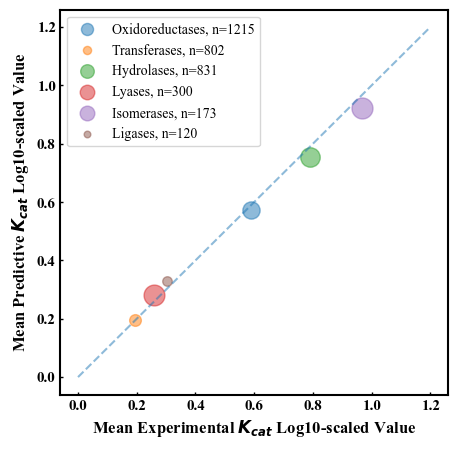

In [22]:
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
import math

plt.figure(figsize=(5,5))
rc('font',**{'family':'Times New Roman', 'weight':'normal'})
plt.rcParams['pdf.fonttype'] = 42
# plt.axes([0.12,0.12,0.83,0.83])
plt.tick_params(direction='in')
plt.tick_params(which='major',length=2)
plt.tick_params(which='major',width=1)

labels = ["Oxidoreductases, n=1215", "Transferases, n=802", "Hydrolases, n=831", "Lyases, n=300", "Isomerases, n=173", "Ligases, n=120", 'Translocases']

if Type == 'kcat':
    x = np.linspace(0, 1.2, 1000)
elif Type == 'km':
    x = np.linspace(-1.0, 0.5, 1000)
else:
    x = np.linspace(0, 2, 1000)
plt.plot(x, x, linestyle='--', alpha=0.5)
for k, v in ECsPerf.items():
    if k != '7':
        if Type == 'kcat':
            plt.scatter(v['meanReal'], v['MeanPre'], s=2.8**(v['MAE']*10), label=labels[int(k)-1], alpha=0.5)
        elif Type == 'km':
            plt.scatter(v['meanReal'], v['MeanPre'], s=2.8**(v['MAE']*10), label=labels[int(k)-1], alpha=0.5)
        else:
            plt.scatter(v['meanReal'], v['MeanPre'], s=2.8**(v['MAE']*10), label=labels[int(k)-1], alpha=0.5)
        print(k,':',v)
        
plt.xticks(fontsize=11, weight='bold')
plt.yticks(fontsize=11, weight='bold')
if Type != 'kkm': 
    plt.ylabel("Mean Predictive $K_{%s}$ Log10-scaled Value"%Type[1:],fontdict={'weight': 'bold', 'fontname': 'Times New Roman', 'size': 12},)
    plt.xlabel("Mean Experimental $K_{%s}$ Log10-scaled Value"%Type[1:],fontdict={'weight': 'bold', 'fontname': 'Times New Roman', 'size': 12},)
else:
    plt.ylabel("Mean Predictive $KK_{%s}$ Log10-scaled Value"%Type[2:],fontdict={'weight': 'bold', 'fontname': 'Times New Roman', 'size': 12},)
    plt.xlabel("Mean Experimental $KK_{%s}$ Log10-scaled Value"%Type[2:],fontdict={'weight': 'bold', 'fontname': 'Times New Roman', 'size': 12},)
plt.legend(markerscale = 0.7)
ax = plt.gca() 
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)

plt.savefig(f"../Fig/Fig2-iter8-MACCSKeys-{Type}-TestDataset.png", dpi=600, bbox_inches='tight')
plt.show()

In [33]:
for k in range(1, 8):
    v = ECsPerf[f'{k}']
    print(f"{v['MAE']:.3f},{v['rmse']:.3f},{v['r2']:.3f},{v['r']:.3f},{v['meanReal']:.3f},{v['MeanPre']:.3f},{v['samples']:.3f}")

0.565,0.829,0.814,0.903,0.861,0.815,425.000
0.561,0.883,0.746,0.864,0.576,0.632,287.000
0.484,0.739,0.780,0.885,1.403,1.325,369.000
0.448,0.649,0.827,0.910,0.401,0.371,138.000
0.491,0.704,0.830,0.914,0.218,0.296,80.000
0.574,0.870,0.787,0.889,0.455,0.343,46.000


KeyError: '7'